# Lab 5 – Backpropagation and Gradient Descent

**Name:** Angsar Shaumen

**Group:** AAI-2501M 

**ID:** 255782

**Date:** 04.02.2026

**Objective:** Implement gradient descent from scratch, visualize loss surfaces & gradients, train a simple neural network on MNIST with SGD, inspect gradients, and compare SGD vs Adam. This notebook is structured for clarity and reproducibility. Run cells top-to-bottom. Explanations precede code cells.

## Setup: imports, seeds

In [86]:
import os
from pathlib import Path
import random
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import datetime

# ML
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, initializers
from tensorflow.keras.datasets import mnist

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Setup complete.")

Setup complete.


## Utility functions

In [87]:
def show_fig(fig):
    fig.tight_layout()
    plt.show()


def save_obj(obj, path):
    with open(path, "wb") as f:
        pickle.dump(obj, f)


def load_obj(path):
    with open(path, "rb") as f:
        return pickle.load(f)

## Part 1 — Gradient Descent Fundamentals (From Scratch)

**Goals**:
- Generate a synthetic linear dataset `y = 3x + 2 + noise` (100 points).
- Implement MSE and gradient descent manually (vectorized numpy).
- Plot loss curve and compare three learning rates: 0.001, 0.01, 0.1.

### Functions for data, loss, and gradient descent


In [88]:
def generate_linear_data(n=100, noise_std=1.0, seed=SEED):
    rng = np.random.RandomState(seed)
    x = np.linspace(-5, 5, n)
    noise = rng.normal(scale=noise_std, size=n)
    y = 3.0 * x + 2.0 + noise
    return x, y


def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def grad_descent(x, y, lr=0.01, epochs=1000, init_w=None, init_b=None, verbose=False):
    # Vectorized gradient descent for linear model y_pred = w*x + b
    if init_w is None:
        w = np.random.RandomState(SEED).randn()
    else:
        w = float(init_w)
    if init_b is None:
        b = np.random.RandomState(SEED+1).randn()
    else:
        b = float(init_b)
    losses = []
    params = []
    n = x.shape[0]
    for i in range(epochs):
        y_pred = w * x + b
        loss = mse(y, y_pred)
        losses.append(loss)
        # analytic gradients
        dw = -2.0 * np.mean(x * (y - y_pred))
        db = -2.0 * np.mean(y - y_pred)
        w = w - lr * dw
        b = b - lr * db
        params.append((w, b))
        if verbose and (i % (max(epochs//5,1)) == 0):
            print(f"iter {i}, loss={loss:.4f}, w={w:.4f}, b={b:.4f}")
    return {"w": w, "b": b, "losses": np.array(losses), "params": params}


### 1.1 Simple Linear Regression

In [89]:
x, y = generate_linear_data(n=100, noise_std=1.0)

lrs = [0.001, 0.01, 0.1]
results = {}
for lr in lrs:
    res = grad_descent(x, y, lr=lr, epochs=1000)
    results[lr] = res

### 1.2 Loss Curve Visualization

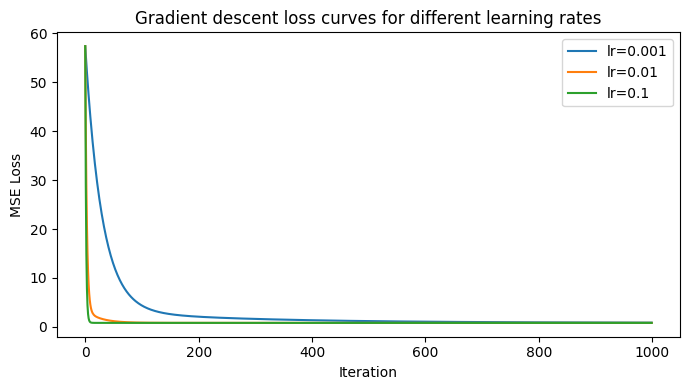

In [90]:
fig, ax = plt.subplots(figsize=(7,4))
for lr, res in results.items():
    ax.plot(res["losses"], label=f"lr={lr}")
ax.set_xlabel("Iteration")
ax.set_ylabel("MSE Loss")
ax.set_title("Gradient descent loss curves for different learning rates")
ax.legend()
show_fig(fig)

### 1.3 Effect of Learning Rate

In [91]:
print("Final parameters and loss:")
for lr, res in results.items():
    print(f"lr={lr}: w={res['w']:.4f}, b={res['b']:.4f}, final_loss={res['losses'][-1]:.6f}")

Final parameters and loss:
lr=0.001: w=3.0138, b=1.6748, final_loss=0.864092
lr=0.01: w=3.0138, b=1.8962, final_loss=0.814905
lr=0.1: w=3.0138, b=1.8962, final_loss=0.814905


- For `lr=0.001`, convergence is slow — loss decreases slowly across iterations.
- For `lr=0.01`, convergence is fast and stable — this is a good learning rate here.
- For `lr=0.1`, training may oscillate or diverge depending on initialization and noise level.

## Part 2 – Visualizing Gradient Descent

**Goal**: Visualize the MSE loss as a function of `(w, b)` to show why gradient descent follows a certain path.


### 2.1 Loss Surface Visualization (Optional but Recommended)

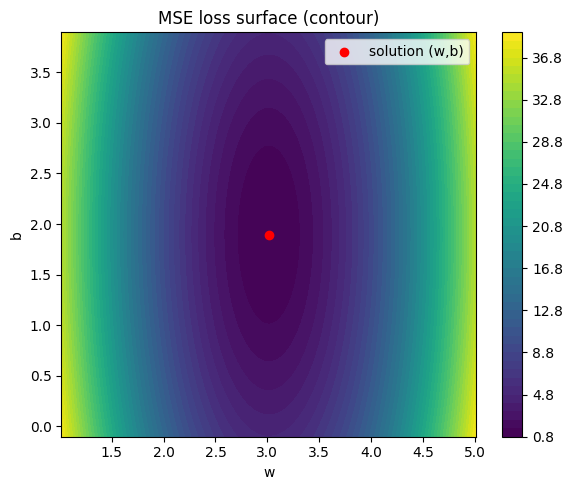

In [92]:
# loss surface (contour)
best_w = results[0.01]['w']
best_b = results[0.01]['b']

# Build grid around learned solution
w_vals = np.linspace(best_w - 2.0, best_w + 2.0, 200)
b_vals = np.linspace(best_b - 2.0, best_b + 2.0, 200)
W, B = np.meshgrid(w_vals, b_vals)

# compute loss grid (vectorized)
# W and B are 2D arrays; we broadcast over sample dimension
Y_pred = W[..., None] * x[None, None, :] + B[..., None]
loss_grid = np.mean((y[None, None, :] - Y_pred) ** 2, axis=-1)

fig, ax = plt.subplots(figsize=(6,5))
cs = ax.contourf(W, B, loss_grid, levels=50)
ax.set_xlabel('w')
ax.set_ylabel('b')
ax.set_title('MSE loss surface (contour)')
fig.colorbar(cs, ax=ax)
ax.scatter([best_w], [best_b], color='red', label='solution (w,b)')
ax.legend()
show_fig(fig)

## Part 3 — Backpropagation with a Neural Network

**Goals**:
- Load MNIST, normalize, flatten inputs.
- Build a small neural network: Dense(64, ReLU) -> Dense(10, Softmax).
- Train with SGD (learning_rate=0.01) and track loss/accuracy.
- Inspect gradients via `tf.GradientTape()`.

### 3.1 Dataset Preparation

In [93]:
# load MNIST and preprocess
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# normalize
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# flatten
x_train_flat = x_train.reshape((-1, 28*28))
x_test_flat = x_test.reshape((-1, 28*28))

print('Shapes:', x_train_flat.shape, y_train.shape, x_test_flat.shape, y_test.shape)

Shapes: (60000, 784) (60000,) (10000, 784) (10000,)


In [94]:
# Build model function (deterministic initializer)
def build_mnist_model(seed=SEED):
    init = initializers.GlorotUniform(seed=seed)
    model = models.Sequential([
        layers.Input(shape=(28*28,)),
        layers.Dense(64, activation='relu', kernel_initializer=init, name='dense_64'),
        layers.Dense(10, activation='softmax', kernel_initializer=init, name='dense_out')
    ])
    return model

### 3.2 Training with Gradient Descent

Epoch 1/10
469/469 - 1s - 3ms/step - accuracy: 0.6504 - loss: 1.3341 - val_accuracy: 0.8411 - val_loss: 0.7190
Epoch 2/10
469/469 - 1s - 2ms/step - accuracy: 0.8545 - loss: 0.6002 - val_accuracy: 0.8777 - val_loss: 0.4852
Epoch 3/10
469/469 - 1s - 3ms/step - accuracy: 0.8782 - loss: 0.4640 - val_accuracy: 0.8904 - val_loss: 0.4079
Epoch 4/10
469/469 - 1s - 2ms/step - accuracy: 0.8903 - loss: 0.4066 - val_accuracy: 0.8989 - val_loss: 0.3682
Epoch 5/10
469/469 - 1s - 2ms/step - accuracy: 0.8974 - loss: 0.3734 - val_accuracy: 0.9036 - val_loss: 0.3434
Epoch 6/10
469/469 - 1s - 2ms/step - accuracy: 0.9024 - loss: 0.3510 - val_accuracy: 0.9078 - val_loss: 0.3260
Epoch 7/10
469/469 - 1s - 2ms/step - accuracy: 0.9063 - loss: 0.3343 - val_accuracy: 0.9111 - val_loss: 0.3127
Epoch 8/10
469/469 - 1s - 2ms/step - accuracy: 0.9099 - loss: 0.3211 - val_accuracy: 0.9131 - val_loss: 0.3020
Epoch 9/10
469/469 - 1s - 2ms/step - accuracy: 0.9127 - loss: 0.3100 - val_accuracy: 0.9152 - val_loss: 0.2929
E

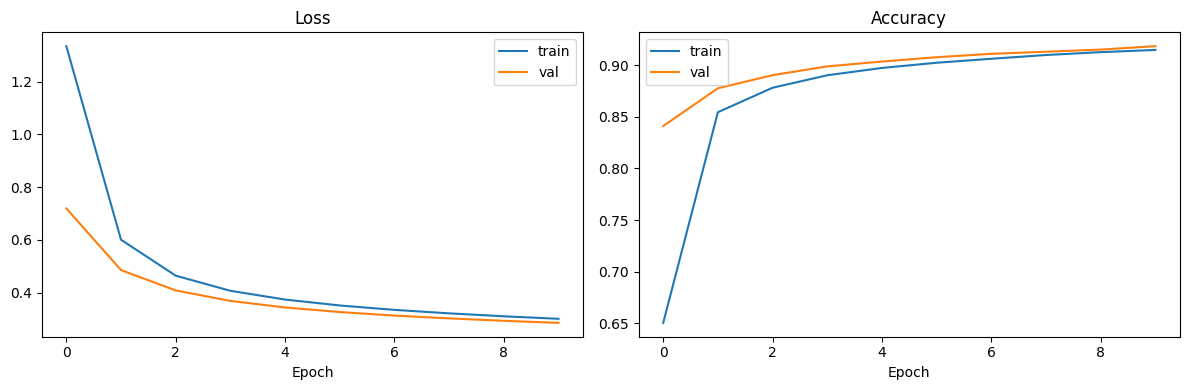

In [95]:
# Train with SGD optimizer
EPOCHS = 10
BATCH_SIZE = 128

model_sgd = build_mnist_model(seed=SEED)
model_sgd.compile(optimizer=optimizers.SGD(learning_rate=0.01), loss=losses.SparseCategoricalCrossentropy(), metrics=['accuracy'])

history_sgd = model_sgd.fit(x_train_flat, y_train, validation_data=(x_test_flat, y_test), epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2)

# Plot training/validation loss and accuracy immediately
fig, axs = plt.subplots(1,2, figsize=(12,4))
axs[0].plot(history_sgd.history['loss'], label='train')
axs[0].plot(history_sgd.history['val_loss'], label='val')
axs[0].set_title('Loss')
axs[0].set_xlabel('Epoch')
axs[0].legend()

axs[1].plot(history_sgd.history['accuracy'], label='train')
axs[1].plot(history_sgd.history['val_accuracy'], label='val')
axs[1].set_title('Accuracy')
axs[1].set_xlabel('Epoch')
axs[1].legend()
show_fig(fig)

### 3.3 Observing Backpropagation
We compute gradients of the loss w.r.t. trainable variables for a single mini-batch and report their norms. Paste summarized results in a small table in your report.


In [96]:
# Take a small batch and compute gradients
batch_x = x_train_flat[:BATCH_SIZE]
batch_y = y_train[:BATCH_SIZE]

with tf.GradientTape() as tape:
    preds = model_sgd(batch_x, training=True)
    loss_value = losses.SparseCategoricalCrossentropy()(batch_y, preds)

grads = tape.gradient(loss_value, model_sgd.trainable_variables)

# Print gradient summaries
grad_summ = []
for var, g in zip(model_sgd.trainable_variables, grads):
    g_arr = g.numpy() if g is not None else None
    norm = float(np.linalg.norm(g_arr)) if g_arr is not None else None
    grad_summ.append({'name': var.name, 'shape': var.shape, 'norm': norm})
    print(f"{var.name:30s} shape={var.shape} norm={norm:.4e}")

kernel                         shape=(784, 64) norm=5.0262e-01
bias                           shape=(64,) norm=5.6897e-02
kernel                         shape=(64, 10) norm=4.0000e-01
bias                           shape=(10,) norm=3.7659e-02


## Part 4 — Comparing Optimizers

**Important**: For a fair comparison, both models must start from the same initial weights. We save initial weights and set them before training each optimizer.


In [97]:
# Save initial weights for reproducibility
base_model = build_mnist_model(seed=SEED)
initial_weights = base_model.get_weights()

### 4.1 SGD vs Adam

In [98]:
# Train with SGD and Adam starting from the same initial weights
def train_with_optimizer(initial_weights, optimizer, opt_name, epochs=10, batch_size=128):
    model = build_mnist_model(seed=SEED)
    model.set_weights(initial_weights)
    model.compile(optimizer=optimizer, loss=losses.SparseCategoricalCrossentropy(), metrics=['accuracy'])
    history = model.fit(x_train_flat, y_train, validation_data=(x_test_flat, y_test), epochs=epochs, batch_size=batch_size, verbose=2)

    return history.history

hist_sgd = train_with_optimizer(initial_weights, optimizers.SGD(learning_rate=0.01), 'SGD', epochs=EPOCHS, batch_size=BATCH_SIZE)
hist_adam = train_with_optimizer(initial_weights, optimizers.Adam(learning_rate=0.001), 'Adam', epochs=EPOCHS, batch_size=BATCH_SIZE)

Epoch 1/10
469/469 - 1s - 2ms/step - accuracy: 0.6504 - loss: 1.3341 - val_accuracy: 0.8411 - val_loss: 0.7190
Epoch 2/10
469/469 - 1s - 2ms/step - accuracy: 0.8545 - loss: 0.6002 - val_accuracy: 0.8777 - val_loss: 0.4852
Epoch 3/10
469/469 - 1s - 2ms/step - accuracy: 0.8782 - loss: 0.4640 - val_accuracy: 0.8904 - val_loss: 0.4079
Epoch 4/10
469/469 - 1s - 2ms/step - accuracy: 0.8903 - loss: 0.4066 - val_accuracy: 0.8989 - val_loss: 0.3682
Epoch 5/10
469/469 - 1s - 2ms/step - accuracy: 0.8974 - loss: 0.3734 - val_accuracy: 0.9036 - val_loss: 0.3434
Epoch 6/10
469/469 - 1s - 2ms/step - accuracy: 0.9024 - loss: 0.3510 - val_accuracy: 0.9078 - val_loss: 0.3260
Epoch 7/10
469/469 - 1s - 2ms/step - accuracy: 0.9063 - loss: 0.3343 - val_accuracy: 0.9111 - val_loss: 0.3127
Epoch 8/10
469/469 - 1s - 2ms/step - accuracy: 0.9099 - loss: 0.3211 - val_accuracy: 0.9131 - val_loss: 0.3020
Epoch 9/10
469/469 - 1s - 2ms/step - accuracy: 0.9127 - loss: 0.3100 - val_accuracy: 0.9152 - val_loss: 0.2929
E

### 4.2 Visualization

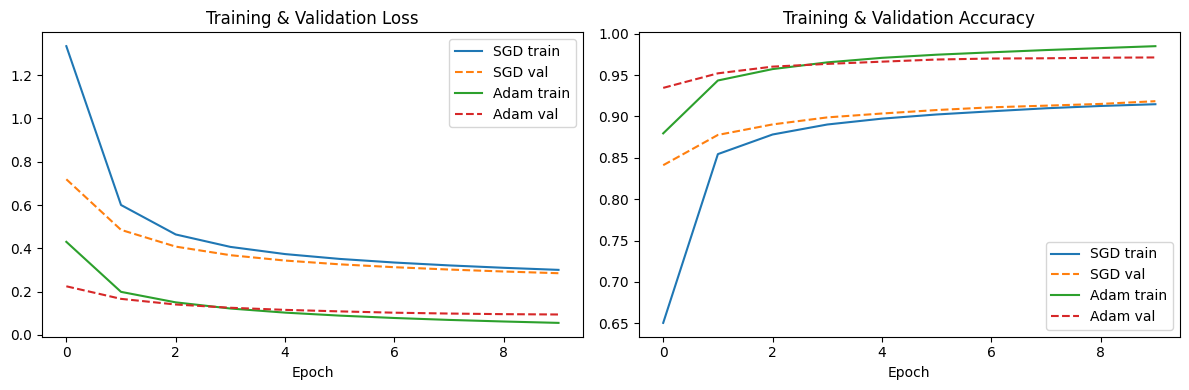

In [99]:
fig, axs = plt.subplots(1,2, figsize=(12,4))
# Loss
axs[0].plot(hist_sgd['loss'], label='SGD train')
axs[0].plot(hist_sgd['val_loss'], label='SGD val', linestyle='--')
axs[0].plot(hist_adam['loss'], label='Adam train')
axs[0].plot(hist_adam['val_loss'], label='Adam val', linestyle='--')
axs[0].set_title('Training & Validation Loss')
axs[0].set_xlabel('Epoch')
axs[0].legend()
# Accuracy
axs[1].plot(hist_sgd['accuracy'], label='SGD train')
axs[1].plot(hist_sgd['val_accuracy'], label='SGD val', linestyle='--')
axs[1].plot(hist_adam['accuracy'], label='Adam train')
axs[1].plot(hist_adam['val_accuracy'], label='Adam val', linestyle='--')
axs[1].set_title('Training & Validation Accuracy')
axs[1].set_xlabel('Epoch')
axs[1].legend()
show_fig(fig)

## Part 5 – Theoretical Questions (Answer Briefly)

**Q1.** What is the role of the **learning rate** in gradient descent?

> The learning rate controls the step size taken along the negative gradient at each update. If it is too small, convergence is slow; if it is too large, updates can overshoot minima and cause divergence or oscillation. A well-chosen learning rate balances speed and stability.

**Q2.** Why do we need **backpropagation** in multi-layer neural networks?

> Backpropagation efficiently computes gradients of the loss with respect to each parameter using the chain rule, reusing intermediate results. Without it, computing gradients would be computationally infeasible for deep networks.

**Q3.** What happens if gradients become very small during training?

> If gradients vanish (very small), parameter updates become negligible, preventing the network (especially earlier layers) from learning — this is the vanishing gradient problem. It can be mitigated by architecture choices, activations, normalization, or different optimizers.

**Q4.** Why does Adam often converge faster than plain SGD?

> Adam adapts learning rates per-parameter using estimates of first and second moments of gradients and includes momentum-like behavior. This lets Adam take larger effective steps on sparse or noisy gradients and often leads to faster, more stable convergence.
